In [1]:
# Install any missing libraries
!pip install gcsfs -q

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# File system access
import gcsfs
import os
import glob

# Signal processing
from scipy import stats
from scipy.signal import welch

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
# Connect to your GCP bucket
fs = gcsfs.GCSFileSystem()

# Define your bucket path
bucket_path = "phm2010-data-temilola/milling"

# List the contents of the bucket
contents = fs.ls(bucket_path)
for item in contents:
    print(item)

phm2010-data-temilola/milling/c1
phm2010-data-temilola/milling/c2
phm2010-data-temilola/milling/c3
phm2010-data-temilola/milling/c4
phm2010-data-temilola/milling/c5
phm2010-data-temilola/milling/c6
phm2010-data-temilola/milling/milling.zip


In [4]:
# Check what's now in the bucket
contents = fs.ls(f"{bucket_path}")
for item in contents:
    print(item)

phm2010-data-temilola/milling/c1
phm2010-data-temilola/milling/c2
phm2010-data-temilola/milling/c3
phm2010-data-temilola/milling/c4
phm2010-data-temilola/milling/c5
phm2010-data-temilola/milling/c6
phm2010-data-temilola/milling/milling.zip


In [5]:
# Verify bucket structure
for cutter in ['c1', 'c2', 'c3', 'c4', 'c5', 'c6']:
    contents = fs.ls(f"{bucket_path}/{cutter}")
    print(f"\n{cutter}:")
    for item in contents:
        print(f"  {item}")


c1:
  phm2010-data-temilola/milling/c1/c1
  phm2010-data-temilola/milling/c1/c1_wear.csv

c2:
  phm2010-data-temilola/milling/c2/c2

c3:
  phm2010-data-temilola/milling/c3/c3

c4:
  phm2010-data-temilola/milling/c4/c4
  phm2010-data-temilola/milling/c4/c4_wear.csv

c5:
  phm2010-data-temilola/milling/c5/c5

c6:
  phm2010-data-temilola/milling/c6/c6
  phm2010-data-temilola/milling/c6/c6_wear.csv


In [7]:
# Load the wear file for c1
wear_c1 = pd.read_csv("gcs://phm2010-data-temilola/milling/c1/c1_wear.csv", header=None)
print(wear_c1.shape)
print(wear_c1.head(10))

(316, 4)
     0            1            2            3
0  cut      flute_1      flute_2      flute_3
1    1  32.31711361  48.89261732  37.72082548
2    2    37.914879  49.57081504  37.72082548
3    3  43.08790971  50.30286727  37.72082548
4    4   47.8590723  51.08365203  37.84985103
5    5  52.25032922  51.90828793  38.17266456
6    6  56.28276562  52.77212655  38.61755643
7    7  59.97661561   53.6707451  39.17455623
8    8   63.3512879   54.5999392  39.83415523
9    9   66.4253909  55.55571585  40.58729178


In [8]:
# Reload with proper header
wear_c1 = pd.read_csv("gcs://phm2010-data-temilola/milling/c1/c1_wear.csv", 
                       header=0,
                       names=['cut', 'flute_1', 'flute_2', 'flute_3'])

# Convert columns to proper numeric types
wear_c1['cut'] = pd.to_numeric(wear_c1['cut'], errors='coerce')
wear_c1['flute_1'] = pd.to_numeric(wear_c1['flute_1'], errors='coerce')
wear_c1['flute_2'] = pd.to_numeric(wear_c1['flute_2'], errors='coerce')
wear_c1['flute_3'] = pd.to_numeric(wear_c1['flute_3'], errors='coerce')

# Add a column for maximum wear across all three flutes
wear_c1['max_wear'] = wear_c1[['flute_1', 'flute_2', 'flute_3']].max(axis=1)

print(wear_c1.shape)
print(wear_c1.head(10))

(315, 5)
   cut    flute_1    flute_2    flute_3   max_wear
0    1  32.317114  48.892617  37.720825  48.892617
1    2  37.914879  49.570815  37.720825  49.570815
2    3  43.087910  50.302867  37.720825  50.302867
3    4  47.859072  51.083652  37.849851  51.083652
4    5  52.250329  51.908288  38.172665  52.250329
5    6  56.282766  52.772127  38.617556  56.282766
6    7  59.976616  53.670745  39.174556  59.976616
7    8  63.351288  54.599939  39.834155  63.351288
8    9  66.425391  55.555716  40.587292  66.425391
9   10  69.216757  56.534286  41.425337  69.216757


In [10]:
# Create a directory to save all plots
import os
os.makedirs('/home/jupyter/plots', exist_ok=True)
print("Plots directory created")

Plots directory created


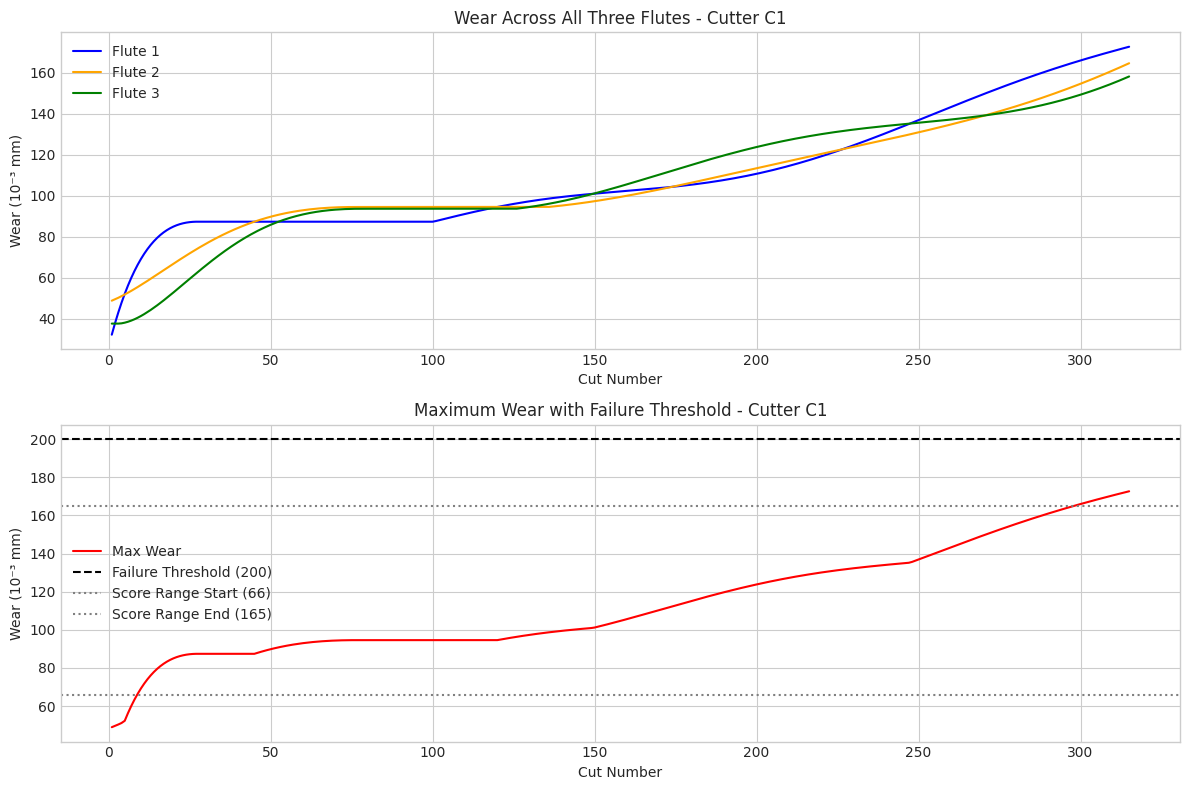

Plot saved


In [11]:
# Plot wear progression for c1
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top plot: all three flutes
axes[0].plot(wear_c1['cut'], wear_c1['flute_1'], label='Flute 1', color='blue')
axes[0].plot(wear_c1['cut'], wear_c1['flute_2'], label='Flute 2', color='orange')
axes[0].plot(wear_c1['cut'], wear_c1['flute_3'], label='Flute 3', color='green')
axes[0].set_title('Wear Across All Three Flutes - Cutter C1')
axes[0].set_xlabel('Cut Number')
axes[0].set_ylabel('Wear (10⁻³ mm)')
axes[0].legend()

# Bottom plot: max wear only with failure threshold
axes[1].plot(wear_c1['cut'], wear_c1['max_wear'], label='Max Wear', color='red')
axes[1].axhline(y=200, color='black', linestyle='--', label='Failure Threshold (200)')
axes[1].axhline(y=66, color='gray', linestyle=':', label='Score Range Start (66)')
axes[1].axhline(y=165, color='gray', linestyle=':', label='Score Range End (165)')
axes[1].set_title('Maximum Wear with Failure Threshold - Cutter C1')
axes[1].set_xlabel('Cut Number')
axes[1].set_ylabel('Wear (10⁻³ mm)')
axes[1].legend()

plt.tight_layout()

# Save the plot
plt.savefig('/home/jupyter/plots/c1_wear_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [12]:
# Load wear files for c4 and c6
wear_c4 = pd.read_csv("gcs://phm2010-data-temilola/milling/c4/c4_wear.csv",
                       header=0,
                       names=['cut', 'flute_1', 'flute_2', 'flute_3'])

wear_c6 = pd.read_csv("gcs://phm2010-data-temilola/milling/c6/c6_wear.csv",
                       header=0,
                       names=['cut', 'flute_1', 'flute_2', 'flute_3'])

# Convert to numeric
for wear_df in [wear_c4, wear_c6]:
    for col in ['cut', 'flute_1', 'flute_2', 'flute_3']:
        wear_df[col] = pd.to_numeric(wear_df[col], errors='coerce')

# Add max wear column
wear_c4['max_wear'] = wear_c4[['flute_1', 'flute_2', 'flute_3']].max(axis=1)
wear_c6['max_wear'] = wear_c6[['flute_1', 'flute_2', 'flute_3']].max(axis=1)

print(f"C4 shape: {wear_c4.shape}, max wear: {wear_c4['max_wear'].max():.1f}, total cuts: {wear_c4['cut'].max()}")
print(f"C6 shape: {wear_c6.shape}, max wear: {wear_c6['max_wear'].max():.1f}, total cuts: {wear_c6['cut'].max()}")

C4 shape: (315, 5), max wear: 210.9, total cuts: 315
C6 shape: (315, 5), max wear: 234.7, total cuts: 315


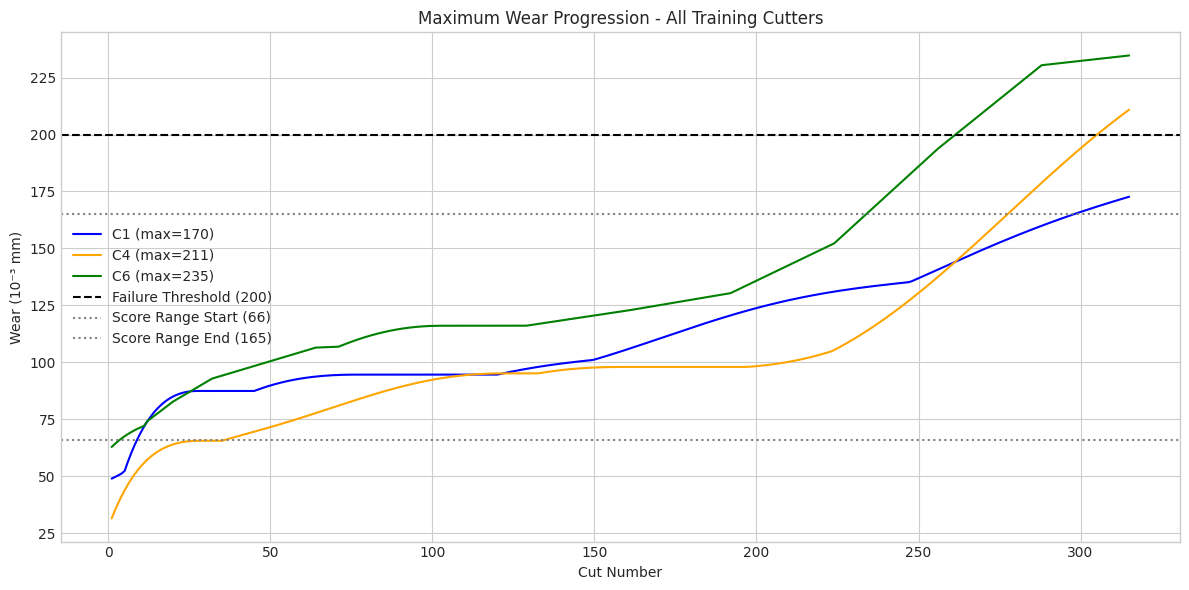

Plot saved


In [13]:
# Plot max wear for all three training cutters together
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(wear_c1['cut'], wear_c1['max_wear'], label='C1 (max=170)', color='blue')
ax.plot(wear_c4['cut'], wear_c4['max_wear'], label='C4 (max=211)', color='orange')
ax.plot(wear_c6['cut'], wear_c6['max_wear'], label='C6 (max=235)', color='green')

ax.axhline(y=200, color='black', linestyle='--', label='Failure Threshold (200)')
ax.axhline(y=66, color='gray', linestyle=':', label='Score Range Start (66)')
ax.axhline(y=165, color='gray', linestyle=':', label='Score Range End (165)')

ax.set_title('Maximum Wear Progression - All Training Cutters')
ax.set_xlabel('Cut Number')
ax.set_ylabel('Wear (10⁻³ mm)')
ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/all_cutters_wear_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [14]:
# Load one sensor file from c1 to understand the structure
sample_file = "gcs://phm2010-data-temilola/milling/c1/c1/c_1_040.csv"

sensor_sample = pd.read_csv(sample_file, header=None,
                             names=['force_x', 'force_y', 'force_z',
                                    'vib_x', 'vib_y', 'vib_z', 'ae_rms'])

print(f"Shape: {sensor_sample.shape}")
print(f"\nFirst 5 rows:")
print(sensor_sample.head())
print(f"\nBasic statistics:")
print(sensor_sample.describe())

Shape: (219058, 7)

First 5 rows:
   force_x  force_y  force_z  vib_x  vib_y  vib_z  ae_rms
0    0.050    2.141   -0.114  0.051  0.032  0.040  -0.005
1    0.170    2.013   -0.044 -0.003 -0.007 -0.002  -0.005
2    0.274    1.851    0.004 -0.030 -0.041 -0.048  -0.004
3    0.370    1.731    0.013  0.093  0.074  0.067  -0.004
4    0.478    1.612    0.069 -0.074 -0.085 -0.087  -0.004

Basic statistics:
             force_x        force_y        force_z          vib_x  \
count  219058.000000  219058.000000  219058.000000  219058.000000   
mean        4.074667       3.299423       3.529326       0.000723   
std         3.729828       7.046820       5.887149       0.087215   
min        -6.321000     -20.452000     -10.868000      -0.384000   
25%         1.011000      -0.948000      -0.932000      -0.056000   
50%         4.183000       2.689000       2.237000       0.001000   
75%         6.939000       6.943000       7.907000       0.058000   
max        14.972000      34.746000      23.671

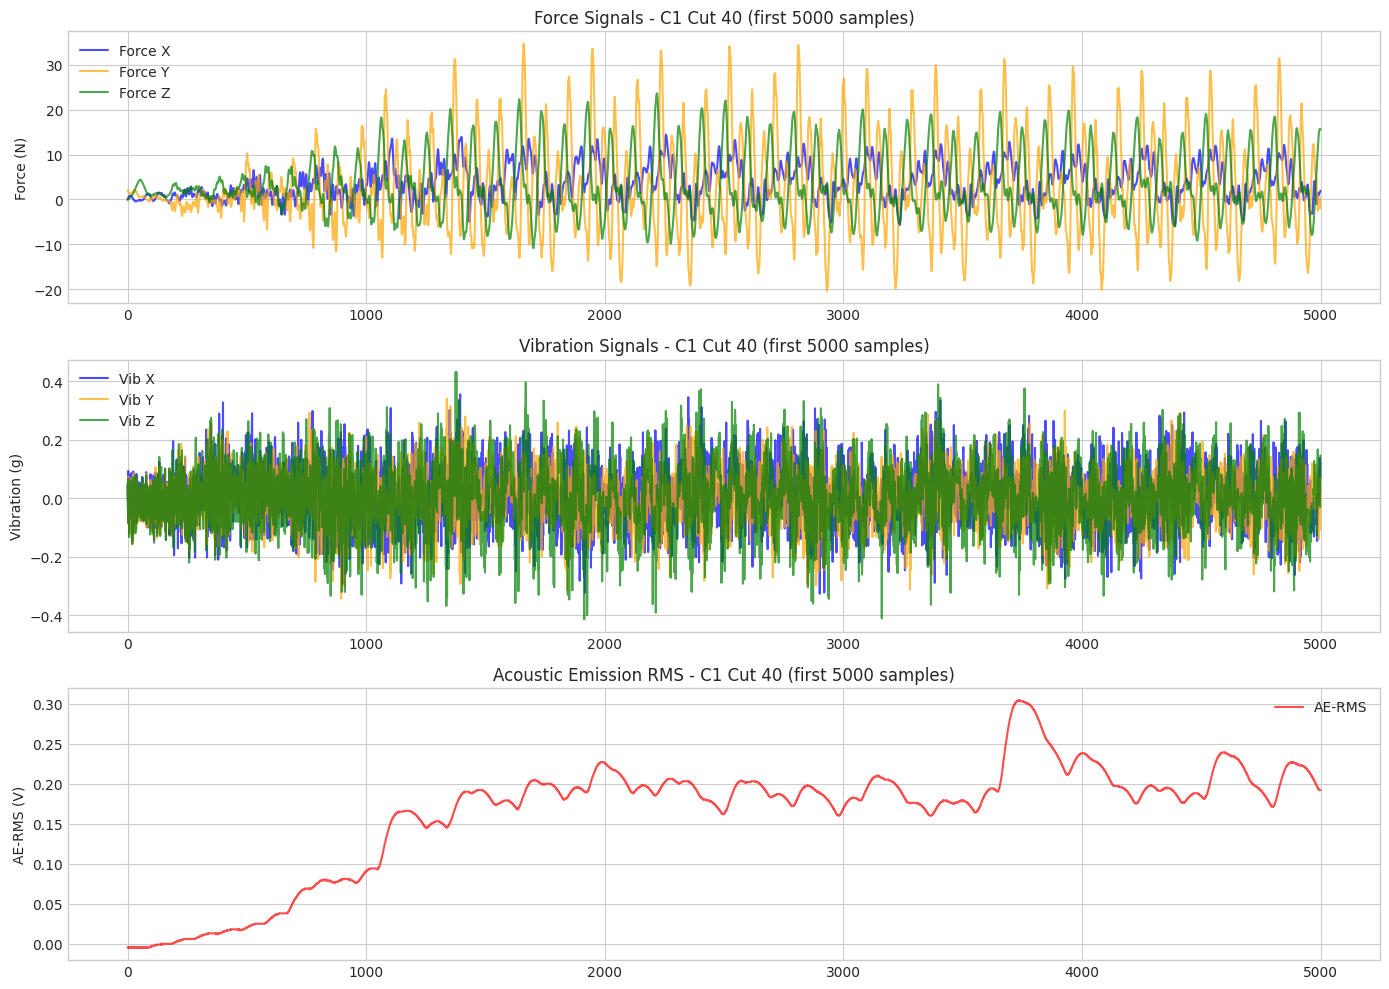

Plot saved


In [15]:
# Plot raw sensor signals for one cut
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot first 5000 rows only so we can see the signal clearly
n = 5000

# Forces
axes[0].plot(sensor_sample['force_x'][:n], label='Force X', color='blue', alpha=0.7)
axes[0].plot(sensor_sample['force_y'][:n], label='Force Y', color='orange', alpha=0.7)
axes[0].plot(sensor_sample['force_z'][:n], label='Force Z', color='green', alpha=0.7)
axes[0].set_title('Force Signals - C1 Cut 40 (first 5000 samples)')
axes[0].set_ylabel('Force (N)')
axes[0].legend()

# Vibrations
axes[1].plot(sensor_sample['vib_x'][:n], label='Vib X', color='blue', alpha=0.7)
axes[1].plot(sensor_sample['vib_y'][:n], label='Vib Y', color='orange', alpha=0.7)
axes[1].plot(sensor_sample['vib_z'][:n], label='Vib Z', color='green', alpha=0.7)
axes[1].set_title('Vibration Signals - C1 Cut 40 (first 5000 samples)')
axes[1].set_ylabel('Vibration (g)')
axes[1].legend()

# AE-RMS
axes[2].plot(sensor_sample['ae_rms'][:n], label='AE-RMS', color='red', alpha=0.7)
axes[2].set_title('Acoustic Emission RMS - C1 Cut 40 (first 5000 samples)')
axes[2].set_ylabel('AE-RMS (V)')
axes[2].legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/sample_sensor_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [16]:
def extract_features(filepath):
    """
    Reads one cut CSV file and extracts statistical features
    from each of the 7 sensor signals.
    Returns a dictionary of 49 features.
    """
    # Read the sensor file
    df = pd.read_csv(filepath, header=None,
                     names=['force_x', 'force_y', 'force_z',
                            'vib_x', 'vib_y', 'vib_z', 'ae_rms'])
    
    features = {}
    
    # Loop through each sensor column
    for col in df.columns:
        signal = df[col].values  # get the column as an array
        
        # Extract 7 features going down the column
        features[f'{col}_mean']     = np.mean(signal)
        features[f'{col}_std']      = np.std(signal)
        features[f'{col}_rms']      = np.sqrt(np.mean(signal**2))
        features[f'{col}_kurtosis'] = stats.kurtosis(signal)
        features[f'{col}_skewness'] = stats.skew(signal)
        features[f'{col}_max']      = np.max(signal)
        features[f'{col}_p2p']      = np.max(signal) - np.min(signal)
    
    return features

Feature extraction function defined


In [ ]:
# Test the function on one file
test_features = extract_features("gcs://phm2010-data-temilola/milling/c1/c1/c_1_040.csv")

# Print all extracted features
for feature_name, value in test_features.items():
    print(f"{feature_name}: {value:.4f}")

In [18]:
def process_cutter(cutter_id, bucket_path, fs):
    """
    Processes all cut files for one cutter and returns
    a dataframe with features and wear labels
    """
    print(f"\nProcessing cutter {cutter_id}...")
    
    # Load wear file
    wear_df = pd.read_csv(f"gcs://{bucket_path}/{cutter_id}/{cutter_id}_wear.csv",
                          header=0,
                          names=['cut', 'flute_1', 'flute_2', 'flute_3'])
    
    # Convert to numeric
    for col in ['cut', 'flute_1', 'flute_2', 'flute_3']:
        wear_df[col] = pd.to_numeric(wear_df[col], errors='coerce')
    
    # Add max wear column
    wear_df['max_wear'] = wear_df[['flute_1', 'flute_2', 'flute_3']].max(axis=1)
    
    # Get all sensor files for this cutter
    sensor_files = fs.ls(f"{bucket_path}/{cutter_id}/{cutter_id}")
    print(f"Found {len(sensor_files)} sensor files")
    
    # Extract features from each file
    all_features = []
    
    for filepath in sorted(sensor_files):
        # Extract cut number from filename e.g. c_1_040.csv -> 40
        filename = filepath.split('/')[-1]
        cut_num = int(filename.split('_')[-1].replace('.csv', ''))
        
        # Extract features
        features = extract_features(f"gcs://{filepath}")
        features['cut'] = cut_num
        features['cutter'] = cutter_id
        
        all_features.append(features)
    
    # Convert to dataframe
    features_df = pd.DataFrame(all_features)
    
    # Merge with wear labels on cut number
    merged_df = features_df.merge(wear_df[['cut', 'max_wear']], on='cut', how='inner')
    
    print(f"Processed {len(merged_df)} cuts with wear labels")
    return merged_df

In [19]:
# Process all three training cutters
df_c1 = process_cutter('c1', bucket_path, fs)
df_c4 = process_cutter('c4', bucket_path, fs)
df_c6 = process_cutter('c6', bucket_path, fs)

# Combine into one master training dataframe
train_df = pd.concat([df_c1, df_c4, df_c6], ignore_index=True)

print(f"\nFinal training dataset shape: {train_df.shape}")
print(f"\nCutter breakdown:")
print(train_df['cutter'].value_counts())
print(f"\nFirst 5 rows:")
print(train_df.head())


Processing cutter c1...
Found 315 sensor files
Processed 315 cuts with wear labels

Processing cutter c4...
Found 315 sensor files
Processed 315 cuts with wear labels

Processing cutter c6...
Found 315 sensor files
Processed 315 cuts with wear labels

Final training dataset shape: (945, 52)

Cutter breakdown:
cutter
c1    315
c4    315
c6    315
Name: count, dtype: int64

First 5 rows:
   force_x_mean  force_x_std  force_x_rms  force_x_kurtosis  force_x_skewness  \
0      0.400857     0.842468     0.932973         -0.245189          0.115205   
1      1.028151     1.864977     2.129609          0.022639          0.606325   
2      1.776092     2.672088     3.208514          0.073317          0.605046   
3      2.104920     2.992555     3.658698          0.102548          0.586804   
4      2.831384     2.979757     4.110436          0.016936          0.612714   

   force_x_max  force_x_p2p  force_y_mean  force_y_std  force_y_rms  \
0        3.744        6.245      0.629463     1.6359

In [20]:
# Save locally
train_df.to_csv('/home/jupyter/train_features.csv', index=False)

# Save to GCS bucket
train_df.to_csv('gcs://phm2010-data-temilola/processed/train_features.csv', index=False)

print("Training dataset saved successfully")
print(f"Shape: {train_df.shape}")

/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Training dataset saved successfully
Shape: (945, 52)


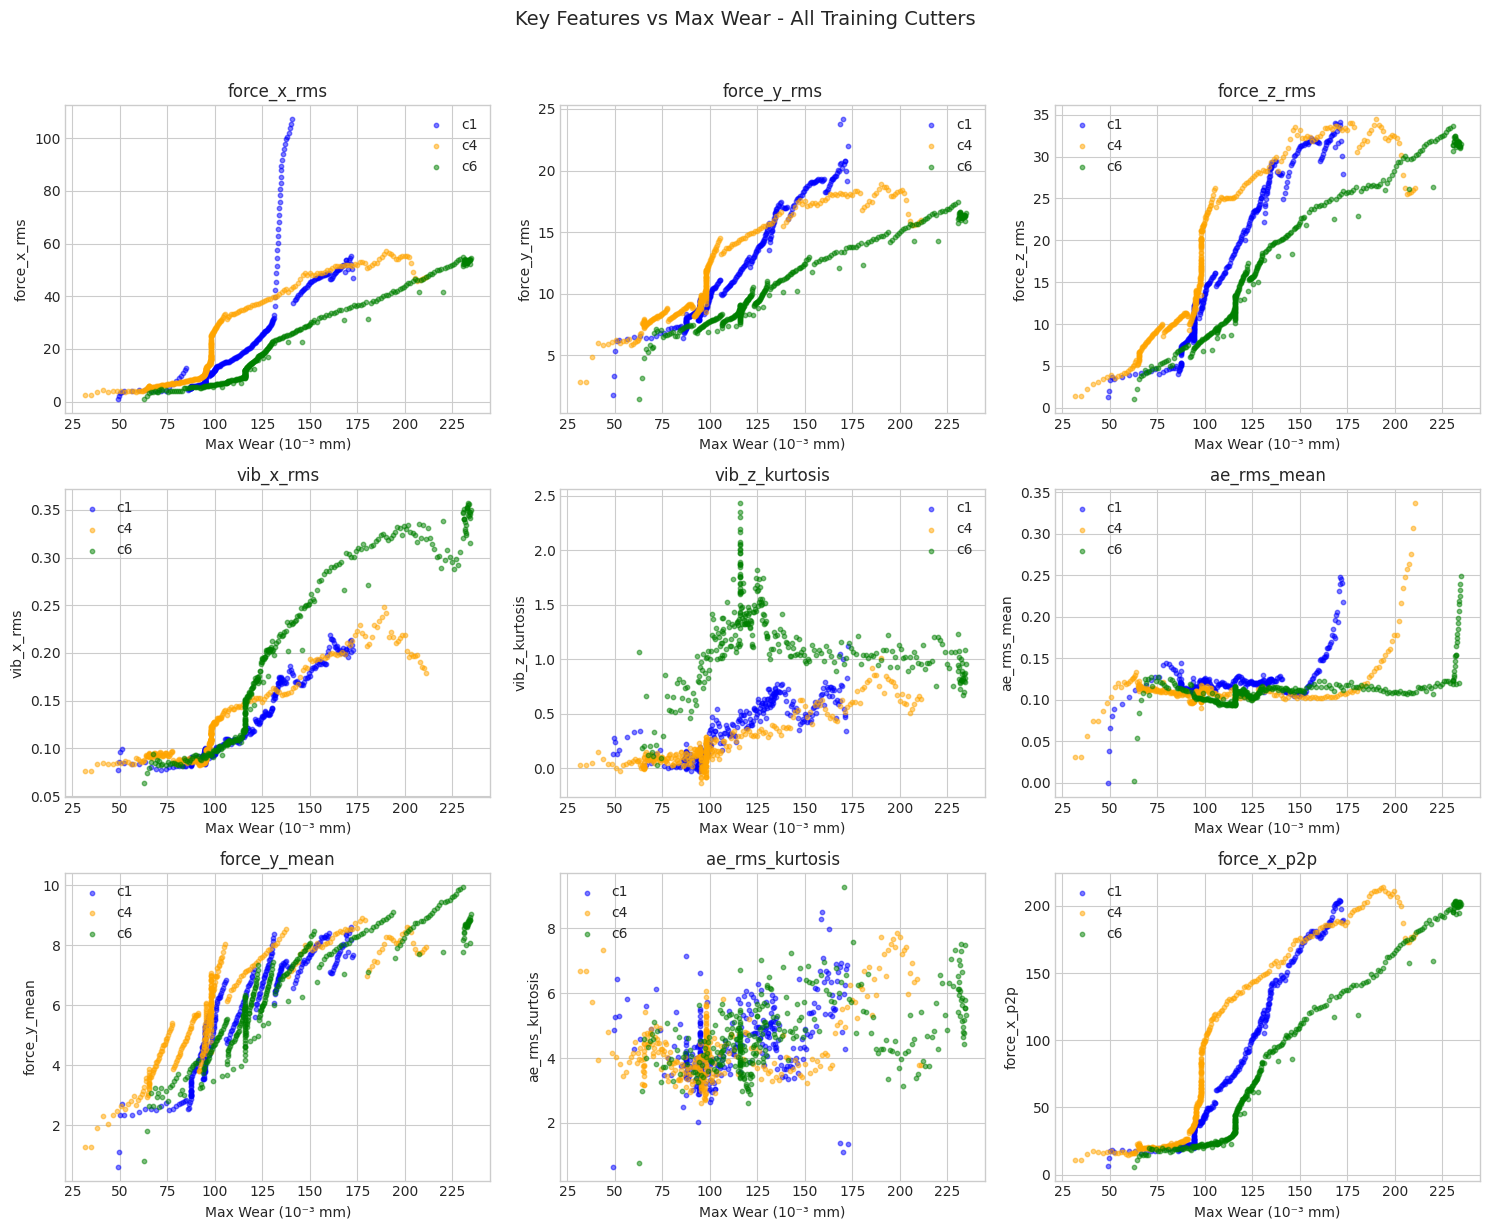

Plot saved


In [21]:
# Plot key features vs max_wear to check correlation
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

features_to_plot = [
    'force_x_rms', 'force_y_rms', 'force_z_rms',
    'vib_x_rms', 'vib_z_kurtosis', 'ae_rms_mean',
    'force_y_mean', 'ae_rms_kurtosis', 'force_x_p2p'
]

colors = {'c1': 'blue', 'c4': 'orange', 'c6': 'green'}

for ax, feature in zip(axes.flatten(), features_to_plot):
    for cutter in ['c1', 'c4', 'c6']:
        subset = train_df[train_df['cutter'] == cutter]
        ax.scatter(subset['max_wear'], subset[feature],
                  label=cutter, color=colors[cutter],
                  alpha=0.5, s=10)
    ax.set_xlabel('Max Wear (10⁻³ mm)')
    ax.set_ylabel(feature)
    ax.set_title(feature)
    ax.legend()

plt.suptitle('Key Features vs Max Wear - All Training Cutters', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('/home/jupyter/plots/features_vs_wear.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [22]:
# Compute correlation of each feature with max_wear
feature_cols = [col for col in train_df.columns 
                if col not in ['cut', 'cutter', 'max_wear']]

correlations = train_df[feature_cols].corrwith(train_df['max_wear'])
correlations = correlations.abs().sort_values(ascending=False)

print("Top 20 features by correlation with max_wear:")
print(correlations.head(20))
print("\nBottom 10 features by correlation with max_wear:")
print(correlations.tail(10))

Top 20 features by correlation with max_wear:
vib_x_std       0.923849
vib_x_rms       0.923666
vib_x_max       0.890391
vib_x_p2p       0.888458
force_x_p2p     0.888281
force_x_std     0.885500
vib_z_std       0.883294
vib_z_rms       0.882567
force_y_mean    0.858990
force_z_rms     0.851207
force_z_std     0.848409
force_z_mean    0.844940
force_x_max     0.844904
vib_z_p2p       0.844185
force_z_max     0.844085
vib_z_max       0.834214
force_z_p2p     0.831629
vib_y_std       0.812480
vib_y_rms       0.811915
vib_y_max       0.811067
dtype: float64

Bottom 10 features by correlation with max_wear:
vib_y_skewness      0.296299
force_x_skewness    0.222828
ae_rms_std          0.194002
force_z_skewness    0.098145
vib_z_skewness      0.096354
ae_rms_skewness     0.077503
vib_x_skewness      0.061834
vib_x_mean          0.028147
vib_y_mean          0.014445
vib_z_mean          0.008507
dtype: float64


In [23]:
# Keep only features with correlation > 0.50
good_features = correlations[correlations > 0.50].index.tolist()
print(f"Number of good features: {len(good_features)}")
print(f"\nSelected features:")
print(good_features)

# Create cleaned training dataset
train_clean = train_df[good_features + ['cut', 'cutter', 'max_wear']].copy()
print(f"\nCleaned dataset shape: {train_clean.shape}")

# Save cleaned dataset
train_clean.to_csv('/home/jupyter/train_clean.csv', index=False)
train_clean.to_csv('gcs://phm2010-data-temilola/processed/train_clean.csv', index=False)
print("Cleaned dataset saved")

Number of good features: 31

Selected features:
['vib_x_std', 'vib_x_rms', 'vib_x_max', 'vib_x_p2p', 'force_x_p2p', 'force_x_std', 'vib_z_std', 'vib_z_rms', 'force_y_mean', 'force_z_rms', 'force_z_std', 'force_z_mean', 'force_x_max', 'vib_z_p2p', 'force_z_max', 'vib_z_max', 'force_z_p2p', 'vib_y_std', 'vib_y_rms', 'vib_y_max', 'vib_y_p2p', 'force_y_rms', 'force_x_rms', 'force_y_std', 'force_y_max', 'force_y_p2p', 'vib_x_kurtosis', 'vib_y_kurtosis', 'force_y_kurtosis', 'force_y_skewness', 'force_x_kurtosis']

Cleaned dataset shape: (945, 34)
Cleaned dataset saved


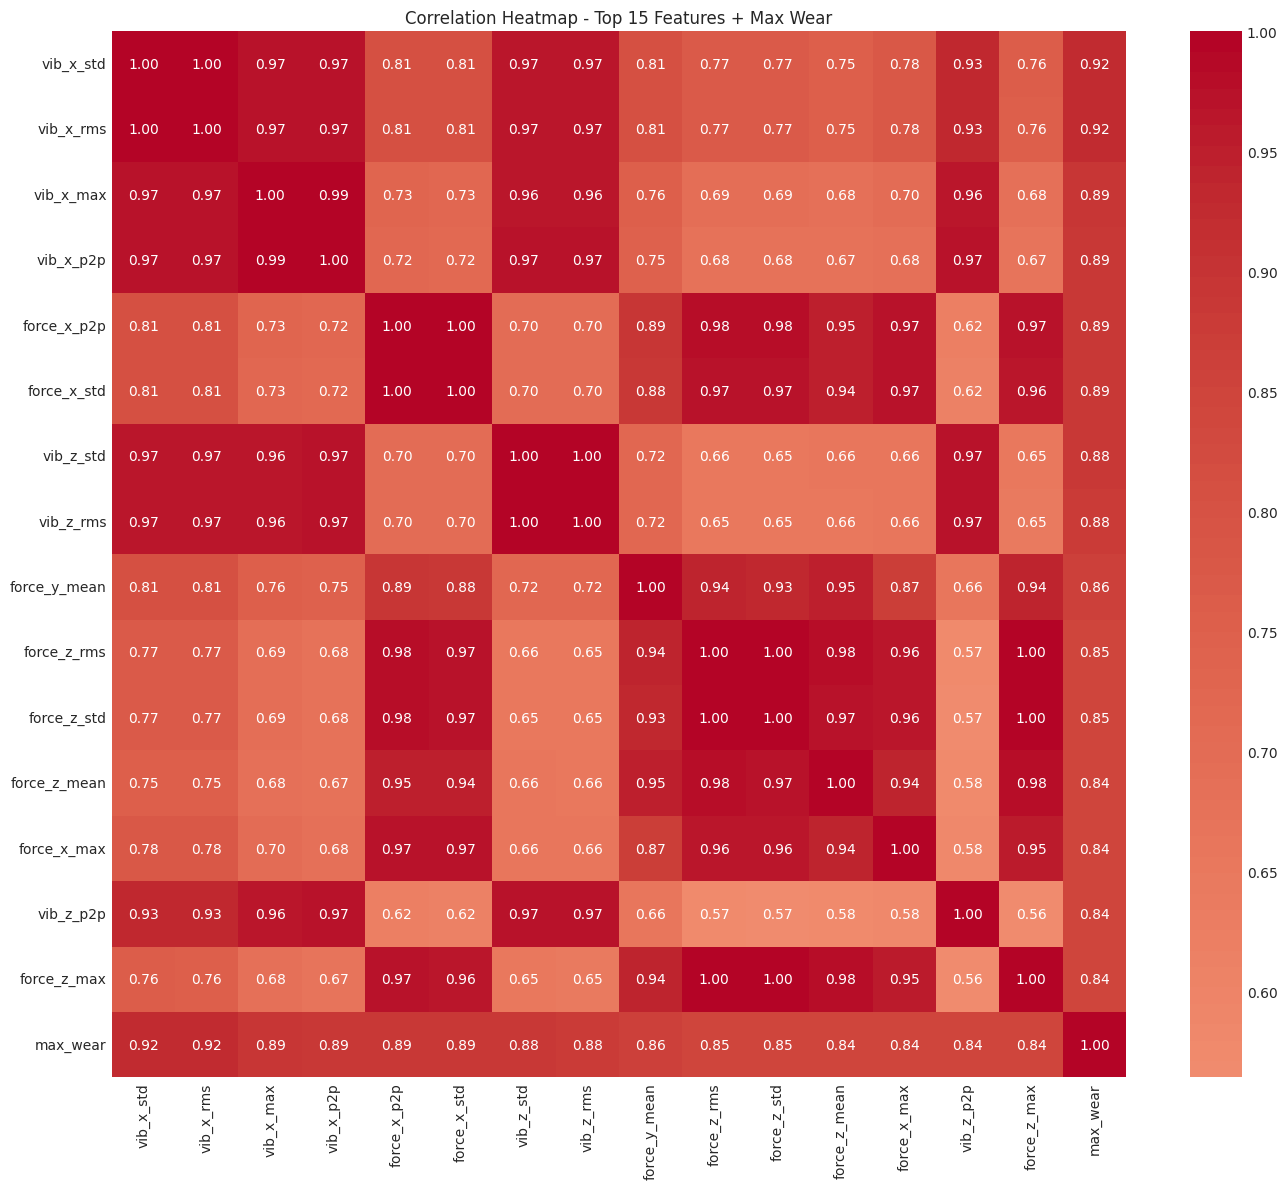

Plot saved


In [24]:
# Correlation heatmap of top 15 features + max_wear
top_15 = correlations.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(14, 12))

corr_matrix = train_clean[top_15 + ['max_wear']].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            ax=ax)

ax.set_title('Correlation Heatmap - Top 15 Features + Max Wear')
plt.tight_layout()
plt.savefig('/home/jupyter/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [27]:
# Drop highly correlated features (threshold = 0.97)
def drop_correlated_features(df, features, threshold=0.97):
    corr_matrix = df[features].corr().abs()
    
    # Get upper triangle of correlation matrix
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Find features to drop
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    
    print(f"Features to drop: {to_drop}")
    print(f"Number of features dropped: {len(to_drop)}")
    
    remaining = [f for f in features if f not in to_drop]
    print(f"Remaining features: {len(remaining)}")
    return remaining

good_features_final = drop_correlated_features(train_clean, good_features)

Features to drop: ['vib_x_rms', 'vib_x_p2p', 'force_x_std', 'vib_z_std', 'vib_z_rms', 'force_z_rms', 'force_z_std', 'force_z_mean', 'vib_z_p2p', 'force_z_max', 'vib_z_max', 'force_z_p2p', 'vib_y_rms', 'vib_y_max', 'vib_y_p2p', 'force_y_rms', 'force_x_rms', 'force_y_std', 'force_y_p2p']
Number of features dropped: 19
Remaining features: 12


In [28]:
print("Final selected features:")
for f in good_features_final:
    print(f"  {f}  (correlation with max_wear: {correlations[f]:.3f})")

Final selected features:
  vib_x_std  (correlation with max_wear: 0.924)
  vib_x_max  (correlation with max_wear: 0.890)
  force_x_p2p  (correlation with max_wear: 0.888)
  force_y_mean  (correlation with max_wear: 0.859)
  force_x_max  (correlation with max_wear: 0.845)
  vib_y_std  (correlation with max_wear: 0.812)
  force_y_max  (correlation with max_wear: 0.743)
  vib_x_kurtosis  (correlation with max_wear: 0.661)
  vib_y_kurtosis  (correlation with max_wear: 0.639)
  force_y_kurtosis  (correlation with max_wear: 0.618)
  force_y_skewness  (correlation with max_wear: 0.572)
  force_x_kurtosis  (correlation with max_wear: 0.563)


In [29]:
# Create final dataset with selected features
train_final = train_clean[good_features_final + ['cut', 'cutter', 'max_wear']].copy()

print(f"Final dataset shape: {train_final.shape}")
print(f"\nSample:")
print(train_final.head())

# Save final dataset
train_final.to_csv('/home/jupyter/train_final.csv', index=False)
train_final.to_csv('gcs://phm2010-data-temilola/processed/train_final.csv', index=False)
print("\nFinal dataset saved")

Final dataset shape: (945, 15)

Sample:
   vib_x_std  vib_x_max  force_x_p2p  force_y_mean  force_x_max  vib_y_std  \
0   0.076349      0.330        6.245      0.629463        3.744   0.076315   
1   0.085350      0.399       12.646      1.118580        8.427   0.085027   
2   0.095641      0.433       17.528      2.347886       11.534   0.093816   
3   0.099032      0.443       17.945      2.721446       11.788   0.097125   
4   0.083672      0.447       16.843      2.351169       12.555   0.081350   

   force_y_max  vib_x_kurtosis  vib_y_kurtosis  force_y_kurtosis  \
0       10.724        0.132293        0.125459          5.844452   
1       14.302        0.275172        0.235982          0.530868   
2       20.826        0.262720        0.194543          0.812980   
3       24.148        0.191981        0.143043          0.681623   
4       24.337        0.303040        0.253101          0.497823   

   force_y_skewness  force_x_kurtosis  cut cutter   max_wear  
0         -0.682218

In [30]:
# Upload plots to bucket
!gsutil -m cp -r /home/jupyter/plots/* gs://phm2010-data-temilola/plots/
print("Plots uploaded to bucket")

Copying file:///home/jupyter/plots/all_cutters_wear_progression.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/c1_wear_progression.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/correlation_heatmap.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/features_vs_wear.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/sample_sensor_signals.png [Content-Type=image/png]...
/ [5/5 files][  1.8 MiB/  1.8 MiB] 100% Done                                    
Operation completed over 5 objects/1.8 MiB.                                      
Plots uploaded to bucket
